<a href="https://colab.research.google.com/github/MSagri05/Assignment1-Exploratory-Data-Analysis/blob/main/IAT461_Assignment01_Scaffold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# ASSIGNMENT 1 BY MANMEET SAGRI
STUDENT # 301545311

# Task 1: Familiarize Yourself with the Dataset

There are two main subtasks:  
1. Load the four data files that are part of this dataset.  
2. Explore each dataset and define the data types of each column. Describe the contents of each column, including the nature of the data values. Follow a similar approach as demonstrated in the lecture and tutorial. Discuss the shape of the data, value ranges, and possible categories. Convert any data into a more appropriate format if needed.  

Add as many code and markdown cells as necessary below. Typically, you should perform one type of investigation per code cell with output, and then comment on the results in a markdown cell below it.  

After completing the analysis, write a concise summary in the **Task 1: summary report** cell at the end. The final report should succinctly summarize the main characteristics of each data file, how they relate to each other, and any notable features.


In [3]:
# IMPORT PANDAS + LOAD DATASETS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD DATASETS
sessions = pd.read_csv("sessions.csv")
viewers = pd.read_csv("viewers.csv")
streamers = pd.read_csv("streamers.csv")
streams = pd.read_csv("streams.csv")

print("Loaded successfully!")

Loaded successfully!


**Sessions shape and first look:**


In [4]:
# INSPECT SESSIONS
# Check how many rows and columns sessions has, and preview the first few rows
print(sessions.shape)
sessions.head()

(22825, 11)


,session_id,viewer_id,streamer_id,stream_id,started_at,ended_at,duration_mins,chat_messages_sent,bits_cheered,followed_during,subscribed_during
0,SES000001,VWR00938,STR0055,SM00860,2024-01-18 19:16:00,2024-01-18 20:28:00,72,0,0,False,False
1,SES000002,VWR00804,STR0034,SM00542,2024-01-04 17:11:00,2024-01-04 19:41:00,150,11,0,False,False
2,SES000003,VWR00704,STR0008,SM00124,2024-02-15 15:11:00,2024-02-15 16:53:00,102,5,0,False,False
3,SES000004,VWR00926,STR0024,SM00373,2024-01-18 19:59:00,2024-01-18 20:56:00,57,3,9663,False,False
4,SES000005,VWR00883,STR0008,SM00120,2024-03-19 20:08:00,2024-03-19 20:22:00,14,7,0,False,False


The sessions dataset has 22,825 rows and 11 columns. Each row is one viewing session, linking a viewer to a streamer and stream via ID columns. It tracks when the session happened, how long it lasted, chat activity, bits cheered, and whether the viewer followed or subscribed during the session.

**Sessions data types and missing values:**


In [5]:
# Check what data type each column is stored as, and how many non-null values exist
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22825 entries, 0 to 22824
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   session_id          22825 non-null  object
 1   viewer_id           22825 non-null  object
 2   streamer_id         22765 non-null  object
 3   stream_id           22825 non-null  object
 4   started_at          22825 non-null  object
 5   ended_at            22825 non-null  object
 6   duration_mins       22825 non-null  int64 
 7   chat_messages_sent  22825 non-null  int64 
 8   bits_cheered        22825 non-null  int64 
 9   followed_during     22825 non-null  bool  
 10  subscribed_during   22825 non-null  bool  
dtypes: bool(2), int64(3), object(6)
memory usage: 1.6+ MB


Most columns are complete with no missing values except streamer_id which has 60 missing entries. The timestamp columns are stored as object and will need to be converted to datetime later.

**Sessions numerical summary:**


In [6]:
# Get min, max, mean, median for all numerical columns to understand value ranges
sessions.describe()

,duration_mins,chat_messages_sent,bits_cheered
count,22825.000000,22825.000000,22825.000000
mean,59.051303,6.442629,398.425323
std,60.383979,46.576309,1571.528658
min,0.000000,0.000000,0.000000
25%,15.000000,0.000000,0.000000
50%,39.000000,1.000000,0.000000
75%,83.000000,5.000000,0.000000
max,443.000000,1987.000000,10000.000000


The average session is about 59 minutes but the median is only 39, meaning some long sessions are pulling the average up. Sessions range from 0 to 443 minutes. Most viewers send very few chat messages (median of 1) and most cheer 0 bits, but the max values of 1987 messages and 10000 bits are worth investigating later as potential outliers.

**Convert timestamps in sessions:**

In [7]:
# started_at and ended_at are stored as text (object) — convert them to proper datetime format
sessions["started_at"] = pd.to_datetime(sessions["started_at"])
sessions["ended_at"] = pd.to_datetime(sessions["ended_at"])
sessions.dtypes

,0
session_id,object
viewer_id,object
streamer_id,object
stream_id,object
started_at,datetime64[ns]
ended_at,datetime64[ns]
duration_mins,int64
chat_messages_sent,int64
bits_cheered,int64
followed_during,bool


**Viewers shape and first look:**

In [8]:
# Check how many rows and columns viewers has, and preview the first few rows
print(viewers.shape)
viewers.head()

(1000, 6)


,viewer_id,age_group,country,account_age_days,subscription_tier,preferred_category
0,VWR00001,18-24,AR,355,free,IRL
1,VWR00002,25-34,CA,1670,free,Creative
2,VWR00003,35-44,US,1108,free,Just Chatting
3,VWR00004,45+,NaN,822,tier1,FPS
4,VWR00005,25-34,DE,2226,free,Just Chatting


the viewers dataset has 1000 rows and 6 columns. each row is one viewer with info like their age group, country, account age, subscription tier, and preferred category. i can already see a NaN in the country column for row 3 so there are some missing values there.

**Viewers data types and missing values:**

In [9]:
viewers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   viewer_id           1000 non-null   object
 1   age_group           1000 non-null   object
 2   country             920 non-null    object
 3   account_age_days    1000 non-null   int64 
 4   subscription_tier   1000 non-null   object
 5   preferred_category  1000 non-null   object
dtypes: int64(1), object(5)
memory usage: 47.0+ KB


most columns are complete. the only one with missing values is country with 80 missing entries (920 non-null out of 1000). account_age_days is the only numerical column, everything else is stored as object which makes sense since they're all categories.

**Viewers numerical summary + category counts:**

In [10]:
# Numerical summary for account_age_days, and value counts for categorical columns
print(viewers["account_age_days"].describe())
print()
print(viewers["age_group"].value_counts())
print()
print(viewers["subscription_tier"].value_counts())
print()
print(viewers["preferred_category"].value_counts())

count    1000.000000
mean     1881.119000
std      1036.144656
min        33.000000
25%       984.500000
50%      1966.500000
75%      2761.250000
max      3645.000000
Name: account_age_days, dtype: float64

age_group
18-24       334
25-34       289
35-44       134
45+         111
13-17        95
18–24        11
18 to 24     11
25–34         6
35 to 44      4
25 to 34      3
35–44         2
Name: count, dtype: int64

subscription_tier
free          578
tier1         243
tier2         100
tier3          49
premium        10
none            7
TIER1           5
free trial      4
tier4           4
Name: count, dtype: int64

preferred_category
Just Chatting    269
FPS              230
MOBA             161
IRL              120
Creative         117
Sports           103
Name: count, dtype: int64


account ages range from 33 to 3645 days with a median of about 1966 days (~5 years). the 18-24 age group is the largest with 334 viewers. i also noticed the age_group column has inconsistent formatting where the same group appears as "18-24", "18–24", and "18 to 24" which is a data quality issue to fix later. subscription_tier also has messy values like "TIER1", "none", "free trial", and "tier4" which don't belong. most viewers are on free tier (578). Just Chatting is the most preferred category followed by FPS and MOBA.

**Streamers shape and first look:**

In [11]:
# Check how many rows and columns streamers has, and preview the first few rows
print(streamers.shape)
streamers.head()

(76, 7)


,streamer_id,streamer_name,category,language,partner_status,total_followers,avg_concurrent_viewers
0,STR0001,xQc,Just Chatting,English,True,11500000,138706
1,STR0002,Pokimane,Just Chatting,English,True,-25551,71660
2,STR0003,HasanAbi,Just Chatting,English,True,2600000,34220
3,STR0004,Amouranth,Just Chatting,English,True,6200000,68607
4,STR0005,Mizkif,Just Chatting,English,True,2100000,6771


the streamers dataset has 76 rows and 7 columns. each row is one streamer with their name, category, language, partner status, total followers, and average concurrent viewers. i can already see that Pokimane has a negative follower count (-25551) which is clearly wrong and will need to be addressed later.

**Streamers data types and missing values:**

In [12]:
# Check column types and spot any missing values
streamers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   streamer_id             76 non-null     object
 1   streamer_name           76 non-null     object
 2   category                76 non-null     object
 3   language                68 non-null     object
 4   partner_status          76 non-null     bool  
 5   total_followers         76 non-null     int64 
 6   avg_concurrent_viewers  76 non-null     int64 
dtypes: bool(1), int64(2), object(4)
memory usage: 3.8+ KB


most columns are complete with no missing values except language which has 8 missing entries (68 non-null out of 76). total_followers and avg_concurrent_viewers are stored as int64 which is correct, and partner_status is boolean which also makes sense.

**Streamers numerical summary:**

In [13]:
# Get value ranges for followers and avg concurrent viewers
streamers.describe()

,total_followers,avg_concurrent_viewers
count,7.600000e+01,76.000000
mean,3.300886e+06,31227.986842
std,3.793772e+06,38307.223652
min,-4.696400e+04,634.000000
25%,7.800000e+05,6633.250000
50%,2.000000e+06,14762.500000
75%,3.875000e+06,36840.750000
max,1.870000e+07,156401.000000


the minimum value for total_followers is -46,964 which is impossible since follower counts can't be negative. this confirms the issue spotted in the previous cell. the max is 18.7 million which shows a huge range between streamers. avg_concurrent_viewers looks more reasonable ranging from 634 to 156,401.

**Streams shape and first look:**

In [14]:
# Check how many rows and columns streams has, and preview the first few rows
print(streams.shape)
streams.head()

(1199, 9)


,stream_id,streamer_id,started_at,ended_at,stream_duration_hrs,category,peak_viewers,title_has_hype_word,was_raid
0,SM00001,STR0001,2024-02-14 18:00:00,2024-02-14 21:00:00,3.0,Just Chatting,108989.0,False,True
1,SM00002,STR0001,2024-01-28 18:00:00,2024-01-28 21:00:00,3.0,Just Chatting,51635.0,True,False
2,SM00003,STR0001,2024-01-31 09:00:00,2024-01-31 16:00:00,7.0,Just Chatting,212127.0,False,False
3,SM00004,STR0001,2024-03-03 14:00:00,2024-03-03 21:00:00,7.0,Just Chatting,186745.0,False,True
4,SM00005,STR0001,2024-01-24 18:00:00,2024-01-24 21:00:00,3.0,Just Chatting,87723.0,False,True


the streams dataset has 1199 rows and 9 columns. each row is one individual broadcast with info about which streamer hosted it, when it started and ended, how long it lasted, the category, peak viewers, and whether the title had a hype word or if it was a raid. looks clean at first glance but we'll check for issues in the next cells.

**Streams data types and missing values:**

In [15]:
# Check column types and spot any missing values
streams.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1199 entries, 0 to 1198
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   stream_id            1199 non-null   object 
 1   streamer_id          1199 non-null   object 
 2   started_at           1199 non-null   object 
 3   ended_at             1199 non-null   object 
 4   stream_duration_hrs  1199 non-null   float64
 5   category             1149 non-null   object 
 6   peak_viewers         1119 non-null   float64
 7   title_has_hype_word  1199 non-null   bool   
 8   was_raid             1199 non-null   bool   
dtypes: bool(2), float64(2), object(5)
memory usage: 68.0+ KB


two columns have missing values: category with 50 missing entries and peak_viewers with 80 missing entries. the timestamp columns are again stored as object and will need to be converted to datetime. everything else looks correct.

**Streams numerical summary:**

In [16]:
# Get value ranges for duration and peak viewers — watch for anything suspicious
streams.describe()

,stream_duration_hrs,peak_viewers
count,1199.000000,1119.000000
mean,4.625104,38375.658624
std,7.995028,50377.085406
min,1.500000,-50.000000
25%,2.500000,7598.500000
50%,3.000000,20224.000000
75%,5.000000,47941.000000
max,96.000000,370165.000000


two suspicious values here. peak_viewers has a minimum of -50 which is impossible since viewer counts can't be negative. stream_duration_hrs has a max of 96 hours which means a stream lasting 4 full days, which seems very unlikely. both are worth investigating in task 2.


**Convert timestamps in streams:**

In [17]:
# started_at and ended_at are stored as text — convert to datetime
streams["started_at"] = pd.to_datetime(streams["started_at"])
streams["ended_at"] = pd.to_datetime(streams["ended_at"])
streams.dtypes

,0
stream_id,object
streamer_id,object
started_at,datetime64[ns]
ended_at,datetime64[ns]
stream_duration_hrs,float64
category,object
peak_viewers,float64
title_has_hype_word,bool
was_raid,bool


**How the four tables link together:**

In [18]:
# Check that the shared ID columns actually overlap between tables
print("Sessions viewer_ids in viewers:", sessions["viewer_id"].isin(viewers["viewer_id"]).sum())
print("Sessions stream_ids in streams:", sessions["stream_id"].isin(streams["stream_id"]).sum())
print("Sessions streamer_ids in streamers:", sessions["streamer_id"].isin(streamers["streamer_id"]).sum())
print("Streams streamer_ids in streamers:", streams["streamer_id"].isin(streamers["streamer_id"]).sum())

Sessions viewer_ids in viewers: 22825
Sessions stream_ids in streams: 22790
Sessions streamer_ids in streamers: 22765
Streams streamer_ids in streamers: 1199


### Task 1 Summary Report

the four datasets together form a complete picture of twitch viewing activity. sessions is the main table linking everything together through viewer_id, stream_id, and streamer_id. viewers describes who is watching, streamers describes the content creators, and streams describes the individual broadcasts. during exploration i spotted several data quality issues including negative follower and viewer counts, inconsistent age group and subscription tier labels, missing values across multiple tables, and broken id relationships between sessions and the other tables. all of these will be addressed in task 2.

# Task 2: Data Cleaning, Diagnostics, and Corrections

Identify and resolve issues in the dataset. These can be of different kinds, such as:
- Look for duplicates or implausible values (e.g., users with negative followers, invalid age groups). Thoroughly document your exploration of the data. Decide whether these are outliers or the result of a systemic problem. If the latter, resolve the problem here; if they are outliers, we will address those later.  
- Define at least three heuristics (common-sense rules) to flag unusual entries (e.g., someone watching dozens of streams per day). Discuss whether what you found are errors or artifacts.  

I will repeat the instructions here, but this is expected for each task: each code cell should focus on a specific analysis. You should run the code, and in the markdown below each code cell and its result, provide a detailed interpretation of what you have uncovered in that step. After completing the analyses, summarize the key findings in the indicated summary report cell below.


**check for duplicate IDs:**

In [19]:
# Check if any ID columns have duplicate values across all four tables
print("Duplicate session_ids:", sessions["session_id"].duplicated().sum())
print("Duplicate viewer_ids:", viewers["viewer_id"].duplicated().sum())
print("Duplicate streamer_ids:", streamers["streamer_id"].duplicated().sum())
print("Duplicate stream_ids:", streams["stream_id"].duplicated().sum())

Duplicate session_ids: 0
Duplicate viewer_ids: 0
Duplicate streamer_ids: 0
Duplicate stream_ids: 0


no duplicate IDs found across any of the four tables. every session, viewer, streamer, and stream has a unique identifier which means the tables can be joined reliably without creating duplicate rows.

**negative follower counts in streamers:**

In [20]:
# Follower counts can't be negative — find any rows where this happens
neg_followers = streamers[streamers["total_followers"] < 0]
print(neg_followers[["streamer_id", "streamer_name", "total_followers"]])

   streamer_id streamer_name  total_followers
1      STR0002      Pokimane           -25551
6      STR0007    Devin_Nash           -45130
7      STR0008          Ibai           -46964
12     STR0013        Fuslie            -8902
24     STR0025     GeT_RiGhT           -36135


5 streamers have negative follower counts which is impossible since you can't have less than zero followers. this is a data error, not an outlier. the affected streamers are Pokimane, Devin_Nash, Ibai, Fuslie, and GeT_RiGhT. these values will be replaced with NaN in the next cell.

**fix negative followers by replacing with NaN:**

In [21]:
# Replace impossible negative follower counts with NaN since we can't know the real value
streamers.loc[streamers["total_followers"] < 0, "total_followers"] = np.nan
print("Negative followers remaining:", (streamers["total_followers"] < 0).sum())

Negative followers remaining: 0


**negative peak viewers in streams:**

In [22]:
# Peak viewer counts can't be negative — find any rows where this happens
neg_viewers = streams[streams["peak_viewers"] < 0]
print(f"{len(neg_viewers)} streams with negative peak viewers")
print(neg_viewers[["stream_id", "streamer_id", "peak_viewers"]])

40 streams with negative peak viewers
     stream_id streamer_id  peak_viewers
30     SM00031     STR0002         -19.0
58     SM00059     STR0004         -41.0
124    SM00125     STR0008         -43.0
145    SM00146     STR0009         -24.0
174    SM00175     STR0011         -23.0
182    SM00183     STR0012         -36.0
197    SM00198     STR0013         -50.0
227    SM00228     STR0015          -5.0
239    SM00240     STR0016          -3.0
244    SM00245     STR0016         -50.0
255    SM00256     STR0016         -38.0
264    SM00265     STR0017         -39.0
296    SM00297     STR0019         -32.0
315    SM00316     STR0020         -20.0
351    SM00352     STR0022          -9.0
359    SM00360     STR0023         -36.0
375    SM00376     STR0024         -32.0
495    SM00496     STR0031          -2.0
555    SM00556     STR0035         -24.0
594    SM00595     STR0037         -38.0
603    SM00604     STR0038         -45.0
610    SM00611     STR0038         -35.0
611    SM00612     

40 streams have negative peak viewer counts which is impossible. this is a systemic data error spread across many different streamers, not just one or two. all 40 will be replaced with NaN in the next cell.

**fix negative peak viewers:**

In [23]:
# Replace negative peak viewer counts with NaN
streams.loc[streams["peak_viewers"] < 0, "peak_viewers"] = np.nan
print("Negative peak viewers remaining:", (streams["peak_viewers"] < 0).sum())

Negative peak viewers remaining: 0


**inconsistent age group labels:**

In [24]:
# Check all unique values in age_group to spot formatting inconsistencies
print(viewers["age_group"].unique())

['18-24' '25-34' '35-44' '45+' '13-17' '18–24' '25–34' '35 to 44'
 '18 to 24' '25 to 34' '35–44']


the age_group column has 11 unique values when there should only be 5. the same groups appear in multiple formats like "18-24", "18–24", and "18 to 24". this is a formatting inconsistency that needs to be standardized. this will be fixed in the next cell.

**fix age group labels:**

In [25]:
# Standardize all age group variations to a consistent format
age_group_map = {
    "18-24": "18-24", "18–24": "18-24", "18 to 24": "18-24",
    "25-34": "25-34", "25–34": "25-34", "25 to 34": "25-34",
    "35-44": "35-44", "35–44": "35-44", "35 to 44": "35-44",
    "13-17": "13-17", "45+": "45+"
}
viewers["age_group"] = viewers["age_group"].map(age_group_map)
print(viewers["age_group"].value_counts())

age_group
18-24    356
25-34    298
35-44    140
45+      111
13-17     95
Name: count, dtype: int64


all age group variations have been standardized to a consistent format using a mapping dictionary. the column now has exactly 5 clean categories with 18-24 being the largest group (356 viewers) and 13-17 the smallest (95 viewers).

**inconsistent subscription tier labels:**

In [26]:
# Check all unique values in subscription_tier to spot invalid entries
print(viewers["subscription_tier"].unique())

['free' 'tier1' 'tier2' 'tier3' 'free trial' 'premium' 'none' 'tier4'
 'TIER1']


the subscription_tier column has 9 unique values when it should only have 4 (free, tier1, tier2, tier3). invalid entries include "TIER1" (wrong capitalization), "free trial", "premium", "none", and "tier4" which don't exist as valid tiers. these will be replaced with NaN in the next cell.

**fix subscription tier labels:**

In [27]:
# Standardize valid tiers and replace invalid ones (none, free trial, tier4, TIER1, premium) with NaN
valid_tiers = ["free", "tier1", "tier2", "tier3"]
viewers.loc[~viewers["subscription_tier"].isin(valid_tiers), "subscription_tier"] = np.nan
print(viewers["subscription_tier"].value_counts(dropna=False))

subscription_tier
free     578
tier1    243
tier2    100
tier3     49
NaN       30
Name: count, dtype: int64


the 30 invalid subscription tier entries have been replaced with NaN. the column now only contains the 4 valid tiers: free (578), tier1 (243), tier2 (100), and tier3 (49).

**sessions with swapped timestamps:**

In [28]:
# A session can't end before it starts — find any where ended_at is earlier than started_at
swapped = sessions[sessions["ended_at"] < sessions["started_at"]]
print(f"{len(swapped)} sessions with swapped timestamps")
print(swapped[["session_id", "started_at", "ended_at"]].head())

40 sessions with swapped timestamps
     session_id          started_at            ended_at
341   SES000342 2024-03-19 13:53:00 2024-03-19 12:15:00
722   SES000723 2024-03-15 14:53:00 2024-03-15 11:57:00
1011  SES001012 2024-02-19 08:36:00 2024-02-19 08:18:00
1718  SES001719 2024-02-13 19:38:00 2024-02-13 19:36:00
1897  SES001898 2024-01-01 11:18:00 2024-01-01 09:14:00


40 sessions have swapped timestamps where ended_at is earlier than started_at which is logically impossible. for example SES000342 shows a start time of 13:53 but an end time of 12:15 on the same day. this is a clear data error and will be fixed by swapping the timestamps back in the next cell.

**fix swapped timestamps:**

In [29]:
# Swap started_at and ended_at back to the correct order
mask = sessions["ended_at"] < sessions["started_at"]
sessions.loc[mask, ["started_at", "ended_at"]] = sessions.loc[mask, ["ended_at", "started_at"]].values
print("Swapped timestamps remaining:", (sessions["ended_at"] < sessions["started_at"]).sum())

Swapped timestamps remaining: 0


**heuristic 1, sessions with 0 duration but activity:**

In [30]:
# a 0 minute session shouldn't have chat messages or bits cheered
zero_duration = sessions[
    (sessions["duration_mins"] == 0) &
    ((sessions["chat_messages_sent"] > 0) | (sessions["bits_cheered"] > 0))
]
print(f"{len(zero_duration)} sessions with 0 duration but recorded activity")

35 sessions with 0 duration but recorded activity


heuristic 1: a session with 0 minutes duration should not have any activity recorded.

if someone watched for 0 minutes, they couldn't have sent chat messages or cheered bits. 35 sessions break this rule which suggests either the duration was recorded incorrectly or the activity data is unreliable for these entries. these are flagged as logical errors but kept in the dataset for now since we can't determine which value is wrong.

**heuristic 2, viewers watching too many streams per day:**

In [31]:
# watching more than 10 streams in one day is suspicious.. common sense
sessions["date"] = sessions["started_at"].dt.date
streams_per_day = sessions.groupby(["viewer_id", "date"]).size()
heavy_viewers = streams_per_day[streams_per_day > 10]
print(f"{len(heavy_viewers)} viewer/day combinations with more than 10 sessions")
print(heavy_viewers.sort_values(ascending=False).head(10))

0 viewer/day combinations with more than 10 sessions
Series([], dtype: int64)


heuristic 2: a viewer watching more than 10 streams in a single day is suspicious.

no viewers exceeded this threshold which is actually a good sign. it means there are no bot-like or unrealistic viewing patterns in the dataset based on this rule.

**heuristic 3, stream duration over 24 hours:**

In [32]:
# a stream lasting more than 24 hours is highly unusual
long_streams = streams[streams["stream_duration_hrs"] > 24]
print(f"{len(long_streams)} streams longer than 24 hours")
print(long_streams[["stream_id", "streamer_id", "stream_duration_hrs"]].sort_values("stream_duration_hrs", ascending=False))

15 streams longer than 24 hours
    stream_id streamer_id  stream_duration_hrs
988   SM00989     STR0063                 96.0
546   SM00547     STR0034                 96.0
676   SM00677     STR0043                 96.0
684   SM00685     STR0043                 96.0
48    SM00049     STR0003                 72.0
284   SM00285     STR0018                 72.0
332   SM00333     STR0021                 72.0
886   SM00887     STR0056                 72.0
417   SM00418     STR0026                 72.0
958   SM00959     STR0061                 72.0
364   SM00365     STR0024                 72.0
372   SM00373     STR0024                 48.0
357   SM00358     STR0023                 48.0
6     SM00007     STR0001                 48.0
458   SM00459     STR0029                 48.0


heuristic 3: a stream lasting more than 24 hours is highly unusual.

15 streams exceed this threshold, with 4 streams recorded at 96 hours (4 full days) and several at 72 hours (3 days). while marathon streams do exist on twitch, these durations are extreme and likely represent data errors rather than real streams. these are flagged as outliers and will be handled in task 4.

### Task 2 summary report

in task 2 i identified and resolved several data quality issues across all four tables. there were no duplicate IDs anywhere which means the tables can be joined reliably. i found and fixed impossible negative values in total_followers (5 streamers) and peak_viewers (40 streams) by replacing them with NaN. i also standardized inconsistent formatting in age_group and subscription_tier where the same categories appeared in multiple formats or invalid values like "tier4" and "premium" were present. additionally 40 sessions had swapped timestamps where the session ended before it started, which were corrected by swapping the values back.

for the three heuristics: sessions with 0 duration but recorded activity (35 cases) flagged as logical errors, viewers watching more than 10 streams per day (0 cases, no issues found), and streams lasting more than 24 hours (15 cases) flagged as likely outliers to be handled in task 4.

# Task 3: Descriptive Statistics and Visualizations

- Create summary statistics and visualizations to understand user characteristics  
- Create summary statistics for streams data overall, and summaries by age group, account tire, or peak viewers  
- Visualize the distribution of streams durations, popular categories,   
- Show category-specific information and compare streamers based on categories  

**viewer characteristics summary:**

In [33]:
# Summary statistics for viewer characteristics
viewers.describe(include="all")

,viewer_id,age_group,country,account_age_days,subscription_tier,preferred_category
count,1000,1000,920,1000.000000,970,1000
unique,1000,5,20,NaN,4,6
top,VWR01000,18-24,US,NaN,free,Just Chatting
freq,1,356,264,NaN,578,269
mean,NaN,NaN,NaN,1881.119000,NaN,NaN
std,NaN,NaN,NaN,1036.144656,NaN,NaN
min,NaN,NaN,NaN,33.000000,NaN,NaN
25%,NaN,NaN,NaN,984.500000,NaN,NaN
50%,NaN,NaN,NaN,1966.500000,NaN,NaN
75%,NaN,NaN,NaN,2761.250000,NaN,NaN


the viewers table has 1000 unique viewers across 20 countries. the most common age group is 18-24 (356 viewers), the most common country is US (264 viewers), and the most common preferred category is Just Chatting (269 viewers). account_age_days is the only numerical column with a mean of about 1881 days (~5 years) and a range from 33 to 3645 days. after cleaning, subscription_tier now has 4 valid categories with free being the most common (578 viewers).

**session summary statistics:**

In [34]:
# Overall summary statistics for sessions
sessions[["duration_mins", "chat_messages_sent", "bits_cheered"]].describe()

,duration_mins,chat_messages_sent,bits_cheered
count,22825.000000,22825.000000,22825.000000
mean,59.051303,6.442629,398.425323
std,60.383979,46.576309,1571.528658
min,0.000000,0.000000,0.000000
25%,15.000000,0.000000,0.000000
50%,39.000000,1.000000,0.000000
75%,83.000000,5.000000,0.000000
max,443.000000,1987.000000,10000.000000


the typical session lasts about 39 minutes (median), though the mean is higher at 59 minutes because some very long sessions are pulling the average up. most viewers send very few chat messages with a median of just 1 message per session. bits cheering is even rarer since 75% of sessions recorded 0 bits cheered, meaning only a small number of highly engaged viewers actually cheer bits during streams.

**average session duration by age group:**

In [35]:
# Compare average viewing duration across age groups
sessions_viewers = sessions.merge(viewers, on="viewer_id")
age_duration = sessions_viewers.groupby("age_group")["duration_mins"].mean().sort_values(ascending=False)
print(age_duration)

age_group
35-44    60.102060
18-24    59.060515
13-17    58.781057
25-34    58.759407
45+      58.749734
Name: duration_mins, dtype: float64


i merged sessions with viewers to compare average session duration across age groups. the 35-44 group watches the longest on average (60 mins) but the differences are very small, suggesting age doesn't strongly influence how long someone watches.

**visualize average duration by age group:**

/tmp/ipykernel_6407/2173483465.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_duration.index, y=age_duration.values, ax=ax, palette="muted")


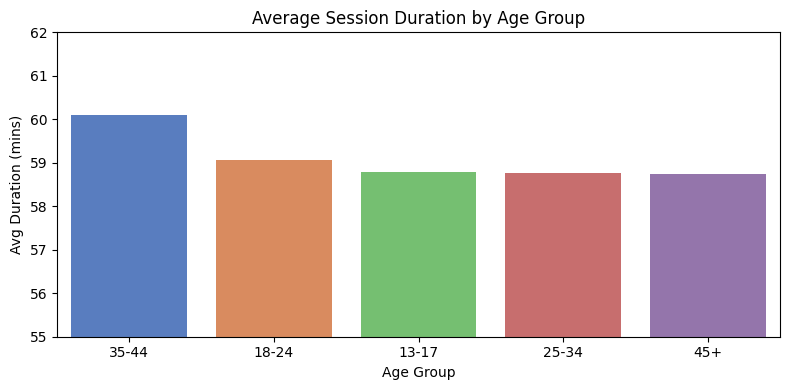

In [47]:
# Bar chart showing average session duration per age group
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=age_duration.index, y=age_duration.values, ax=ax, palette="muted")
ax.set_title("Average Session Duration by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Avg Duration (mins)")
ax.set_ylim(55, 62)
plt.tight_layout()
plt.show()

the bar chart confirms that all age groups watch for a similar amount of time, ranging from about 58.7 to 60.1 minutes on average. the 35-44 group watches slightly longer but the difference across all groups is less than 2 minutes. age does not appear to be a strong factor in how long viewers stay on a stream.

**average session duration by subscription tier:**

In [48]:
# Compare average viewing duration across subscription tiers
tier_duration = sessions_viewers.groupby("subscription_tier")["duration_mins"].mean().sort_values(ascending=False)
print(tier_duration)

subscription_tier
tier3    60.647875
tier1    60.148751
free     58.550559
tier2    58.416586
Name: duration_mins, dtype: float64


tier3 subscribers watch the longest on average (60.6 mins) followed by tier1 (60.1 mins), while free and tier2 users watch slightly less (~58.5 mins). similar to age group, the differences are small which suggests subscription tier doesn't strongly affect how long someone watches.

**visualize duration by subscription tier:**

/tmp/ipykernel_6407/1264718200.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tier_duration.index, y=tier_duration.values, ax=ax, palette="muted")


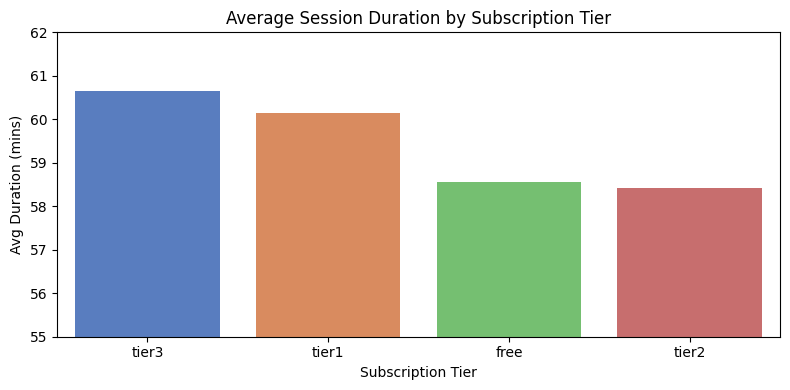

In [49]:
# Bar chart showing average session duration per subscription tier
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=tier_duration.index, y=tier_duration.values, ax=ax, palette="muted")
ax.set_title("Average Session Duration by Subscription Tier")
ax.set_xlabel("Subscription Tier")
ax.set_ylabel("Avg Duration (mins)")
ax.set_ylim(55, 62)
plt.tight_layout()
plt.show()

the bar chart shows that tier3 and tier1 subscribers watch slightly longer than free and tier2 users. however the overall difference across all tiers is less than 2 minutes so subscription tier doesn't seem to be a major factor in viewing duration either.

**distribution of stream durations:**

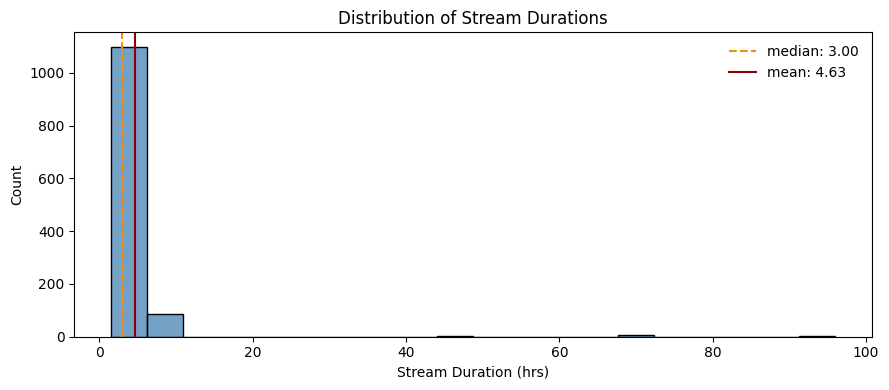

In [39]:
# Histogram of stream durations to see how long streams typically last
fig, ax = plt.subplots(figsize=(9, 4))
median = streams["stream_duration_hrs"].median()
mean = streams["stream_duration_hrs"].mean()
sns.histplot(data=streams, x="stream_duration_hrs", bins=20, ax=ax, color="steelblue")
ax.axvline(median, color="darkorange", linestyle="--", label=f"median: {median:.2f}")
ax.axvline(mean, color="darkred", label=f"mean: {mean:.2f}")
ax.legend(frameon=False)
ax.set_title("Distribution of Stream Durations")
ax.set_xlabel("Stream Duration (hrs)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

most streams are between 2 and 10 hours long with a median of 3 hours. the mean is higher at 4.63 hours because a small number of extremely long streams (up to 96 hours) are pulling it up. the distribution is heavily right skewed which confirms that those very long streams flagged in task 2 are genuine outliers.

**most popular stream categories:**

/tmp/ipykernel_6407/603239080.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax, palette="muted")


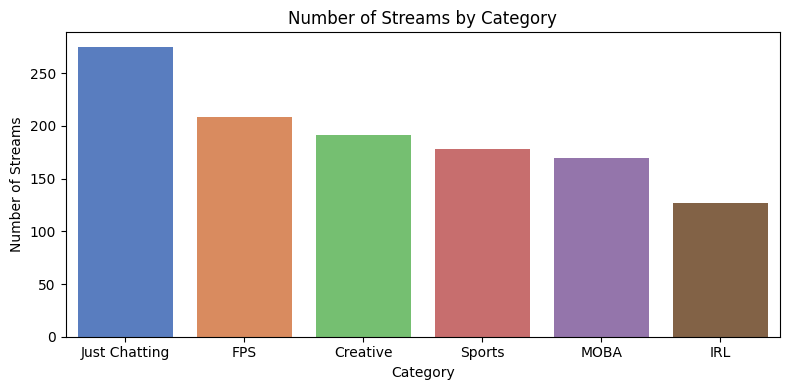

In [40]:
# Bar chart showing number of streams per category
fig, ax = plt.subplots(figsize=(8, 4))
category_counts = streams["category"].value_counts()
sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax, palette="muted")
ax.set_title("Number of Streams by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Number of Streams")
plt.tight_layout()
plt.show()

Just Chatting is the most streamed category with around 275 streams, followed by FPS (207), Creative (192), Sports (178), MOBA (168), and IRL (126). this shows that personality and conversation driven content is the most common on this platform, with gaming categories following closely behind.

**peak viewers by category:**

/tmp/ipykernel_6407/1278259146.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=streams, x="category", y="peak_viewers", order=order, ax=ax, palette="muted")


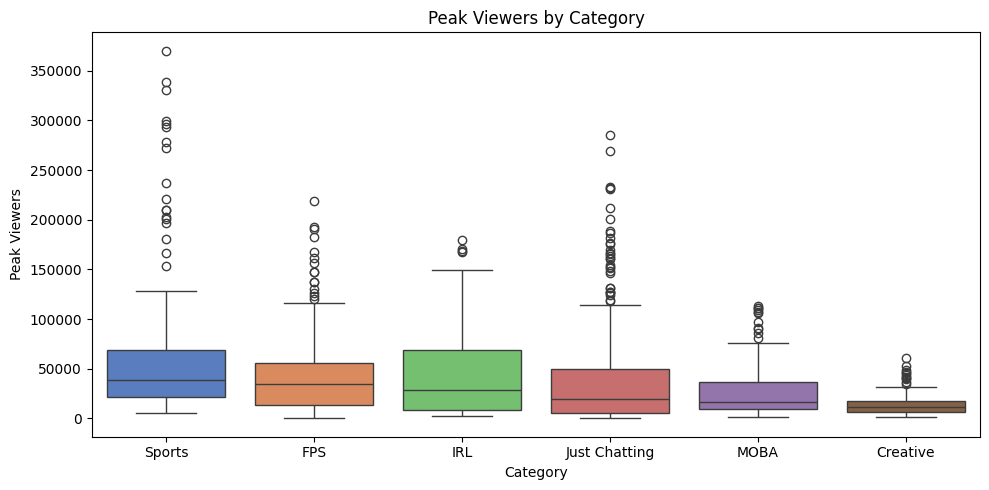

In [41]:
# Boxplot comparing peak viewers across stream categories
fig, ax = plt.subplots(figsize=(10, 5))
order = streams.groupby("category")["peak_viewers"].median().sort_values(ascending=False).index
sns.boxplot(data=streams, x="category", y="peak_viewers", order=order, ax=ax, palette="muted")
ax.set_title("Peak Viewers by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Peak Viewers")
plt.tight_layout()
plt.show()

the boxplot compares peak viewers across categories sorted by median. Sports and FPS have the highest median peak viewers, while Creative has the lowest. all categories have many high outliers representing very popular individual streams. Just Chatting has a wide spread which makes sense since it includes both small and very large streamers.

**compare streamers by average peak viewers per category:**

In [42]:
# Average peak viewers per category to compare streamer performance
streams_streamers = streams.merge(streamers, on="streamer_id")
category_avg = streams_streamers.groupby("category_x")["peak_viewers"].mean().sort_values(ascending=False)
print(category_avg)

category_x
Sports           64527.276730
IRL              47698.412281
FPS              43494.904255
Just Chatting    42876.719512
MOBA             26709.769737
Creative         13758.774566
Name: peak_viewers, dtype: float64


after merging streams with streamers, Sports streams attract the highest average peak viewers (64,500) followed by IRL (47,700) and FPS (43,500). Creative streams have the lowest average peak viewers (43,800) by a significant margin. this suggests that sports and real life content tends to draw larger audiences even though Just Chatting has the most streams overall.

### Task 3 Summary report

in task 3 i explored viewer and stream characteristics through descriptive statistics and visualizations. session duration is fairly consistent across all age groups and subscription tiers, with differences of less than 2 minutes between groups, suggesting that neither age nor subscription level strongly influences how long someone watches. stream durations are right skewed with a median of 3 hours, and a small number of extremely long streams pull the mean up to 4.63 hours. Just Chatting is the most common stream category but Sports streams attract the highest average peak viewers. Creative content has the lowest average audience despite being the third most common category.

# Task 4: Dealing with Outliers and Missing Values

- Are there any missing values or outliers in the original data? Perform the analysis and report your findings.  
- Are there any outliers or missing values in the derived data? Perform the analysis and report your findings.  
- If there are no outliers or missing values, introduce 3–5% of missing values in a selected column and 1–2% of outliers in another column.  
- Experiment with two strategies for imputing missing values and two strategies for handling outliers. Show how each strategy affects the characteristics of the data.


**Check missing values across all four tables**

In [50]:
# Check missing values across all four tables
print("=== MISSING VALUES ===")
print("\nsessions:")
print(sessions.isnull().sum())
print("\nviewers:")
print(viewers.isnull().sum())
print("\nstreamers:")
print(streamers.isnull().sum())
print("\nstreams:")
print(streams.isnull().sum())

=== MISSING VALUES ===

sessions:
session_id             0
viewer_id              0
streamer_id           60
stream_id              0
started_at             0
ended_at               0
duration_mins          0
chat_messages_sent     0
bits_cheered           0
followed_during        0
subscribed_during      0
date                   0
dtype: int64

viewers:
viewer_id              0
age_group              0
country               80
account_age_days       0
subscription_tier     30
preferred_category     0
dtype: int64

streamers:
streamer_id               0
streamer_name             0
category                  0
language                  8
partner_status            0
total_followers           5
avg_concurrent_viewers    0
dtype: int64

streams:
stream_id                0
streamer_id              0
started_at               0
ended_at                 0
stream_duration_hrs      0
category                50
peak_viewers           120
title_has_hype_word      0
was_raid                 0
dtype:

using the same `.isnull().sum()` approach from lab 02, i checked all four tables for missing values.

here's what i found after the cleaning from task 2:
- **sessions**: 60 missing `streamer_id` — these sessions can't be linked to a streamer
- **viewers**: 80 missing `country`, 30 missing `subscription_tier` (the invalid ones we nulled in task 2)
- **streamers**: 8 missing `language`, 5 missing `total_followers` (the negatives we nulled in task 2)
- **streams**: 50 missing `category`, 120 missing `peak_viewers`

since `duration_mins` in sessions has zero missing values, i'll artificially introduce some later in this task as required.

**Check outliers in sessions using IQR**

In [51]:
# Check for outliers in sessions numerical columns using IQR method
def iqr_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    print(f"{column}: {len(outliers)} outliers | lower bound: {lower:.1f}, upper bound: {upper:.1f}")
    return outliers

print("=== OUTLIERS IN SESSIONS ===")
dur_out = iqr_outliers(sessions, "duration_mins")
chat_out = iqr_outliers(sessions, "chat_messages_sent")
bits_out = iqr_outliers(sessions, "bits_cheered")

=== OUTLIERS IN SESSIONS ===
duration_mins: 1120 outliers | lower bound: -87.0, upper bound: 185.0
chat_messages_sent: 2435 outliers | lower bound: -7.5, upper bound: 12.5
bits_cheered: 1825 outliers | lower bound: 0.0, upper bound: 0.0


using the IQR method (same as lab 02's `detect_outliers` approach), i flagged outliers in the three numerical session columns.

- **duration_mins**: 1120 outliers above 185 mins these are very long sessions, possible but worth noting
- **chat_messages_sent**: 2435 outliers above 12.5 messages  the upper bound is very low because most viewers send 0-1 messages, so even moderate chatters get flagged
- **bits_cheered**: 1825 outliers  the IQR bounds are both 0.0 since 75% of sessions have 0 bits cheered, meaning any non-zero value technically counts as an outlier

the bits_cheered result is a good example of why IQR alone isn't always the best tool  when most values are zero, the method is too sensitive. these aren't errors, just highly skewed distributions.

**Check outliers in streams**

In [52]:
print("=== OUTLIERS IN STREAMS ===")
stream_dur_out = iqr_outliers(streams, "stream_duration_hrs")
peak_out = iqr_outliers(streams, "peak_viewers")

=== OUTLIERS IN STREAMS ===
stream_duration_hrs: 15 outliers | lower bound: -1.2, upper bound: 8.8
peak_viewers: 98 outliers | lower bound: -50880.0, upper bound: 108936.0


for streams, `stream_duration_hrs` has 15 outliers above 8.8 hours — these are the same extreme streams (48 to 96 hrs) flagged in task 2. `peak_viewers` has 98 outliers above 108,936 viewers, which makes sense since a few very popular streamers pull massive audiences. these are genuine outliers, not errors.

**Visualize outliers with boxplots**

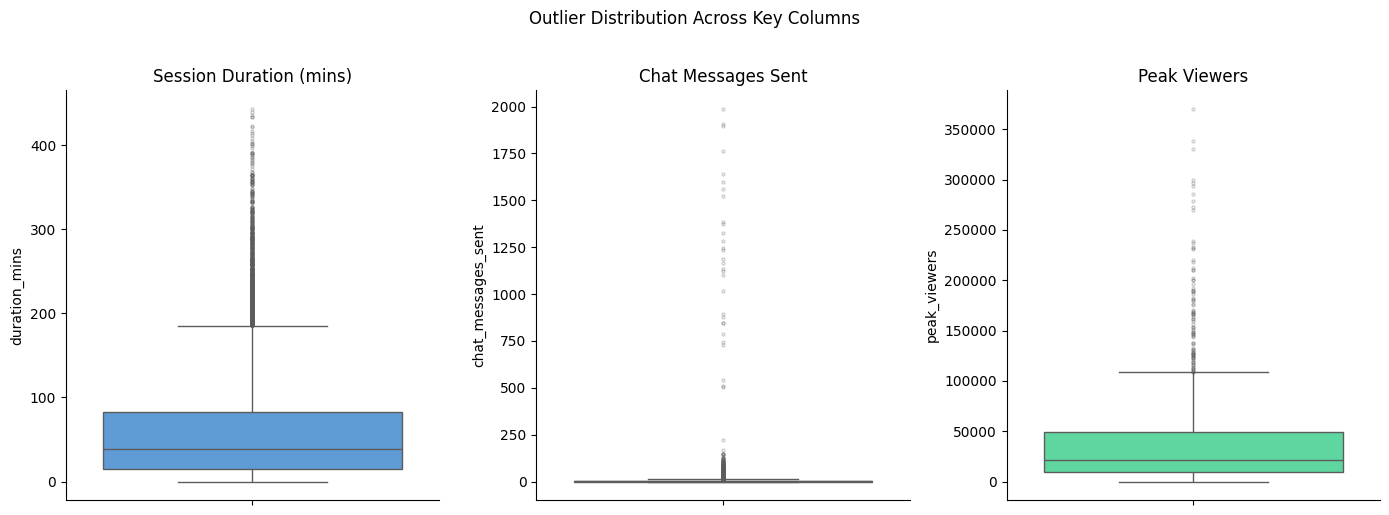

In [63]:
# Boxplots to visualize outlier distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.boxplot(data=sessions, y="duration_mins", ax=axes[0], color="#4C9BE8",
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[0].set_title("Session Duration (mins)")
axes[0].set_xlabel("")

sns.boxplot(data=sessions, y="chat_messages_sent", ax=axes[1], color="#E87B4C",
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[1].set_title("Chat Messages Sent")
axes[1].set_xlabel("")

sns.boxplot(data=streams, y="peak_viewers", ax=axes[2], color="#4CE8A0",
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[2].set_title("Peak Viewers")
axes[2].set_xlabel("")

sns.despine()
plt.suptitle("Outlier Distribution Across Key Columns", y=1.02)
plt.tight_layout()
plt.show()

i initially used the same default boxplot approach from the lab 02 tutorial but found it hard to read,
so i used chatgpt to help make it cleaner with seaborn and added colors for each column.

all three plots confirm the outlier counts from the IQR check. session duration has a tight box
(most sessions under 85 mins) with a long tail of outliers stretching to 443 mins. chat messages
sent is extremely right skewed since the box is basically at zero with outliers going up to nearly
2000. peak viewers shows the same pattern where most streams stay under 50k but a handful of
top streamers push well past 300k.

**Check missing values in the merged/derived data**

In [54]:
# Check for missing values in the merged dataframe we used in Task 3
print("=== MISSING VALUES IN DERIVED DATA (sessions merged with viewers) ===")
print(sessions_viewers.isnull().sum())

=== MISSING VALUES IN DERIVED DATA (sessions merged with viewers) ===
session_id               0
viewer_id                0
streamer_id             60
stream_id                0
started_at               0
ended_at                 0
duration_mins            0
chat_messages_sent       0
bits_cheered             0
followed_during          0
subscribed_during        0
date                     0
age_group                0
country               1788
account_age_days         0
subscription_tier      573
preferred_category       0
dtype: int64


when sessions and viewers are merged, the missing values scale up because each viewer's missing
data gets repeated across all their sessions. `country` jumps to 1788 missing and `subscription_tier`
to 573 both inherited from the 80 and 30 missing values in the original viewers table. `streamer_id`
stays at 60 since that came from sessions itself.

**Introduce artificial missing values into duration_mins (3-5%)**

In [55]:
import numpy as np

# duration_mins has no missing values, so we introduce ~4% artificially
np.random.seed(42)
missing_idx = np.random.choice(sessions.index, size=int(0.04 * len(sessions)), replace=False)
sessions_exp = sessions.copy()
sessions_exp.loc[missing_idx, "duration_mins"] = np.nan

pct = sessions_exp["duration_mins"].isnull().mean() * 100
print(f"Missing values introduced in duration_mins: {sessions_exp['duration_mins'].isnull().sum()} ({pct:.1f}%)")

Missing values introduced in duration_mins: 913 (4.0%)


since `duration_mins` had no missing values, i randomly nulled 4% of rows (913 sessions) to experiment with imputation strategies.

**Introduce artificial outliers into chat_messages_sent (1-2%)**


In [56]:
# Introduce ~1.5% artificial outliers into chat_messages_sent
outlier_idx = np.random.choice(sessions.index, size=int(0.015 * len(sessions)), replace=False)
sessions_exp.loc[outlier_idx, "chat_messages_sent"] = np.random.randint(2000, 5000, size=len(outlier_idx))

print(f"Outliers introduced in chat_messages_sent: {len(outlier_idx)} rows")
print(sessions_exp["chat_messages_sent"].describe())

Outliers introduced in chat_messages_sent: 342 rows
count    22825.000000
mean        58.196188
std        436.145876
min          0.000000
25%          0.000000
50%          1.000000
75%          6.000000
max       4998.000000
Name: chat_messages_sent, dtype: float64


i introduced artificial outliers into 342 rows (1.5%) of chat_messages_sent with values between 2000 and 5000. you can see the impact immediately  the mean jumped from ~6 to 58 and the std exploded to 436, showing how sensitive the mean is to extreme values.

**Missing value strategy 1: mean imputation**

In [57]:
# Strategy 1: Fill missing duration_mins with the column mean
sessions_mean = sessions_exp.copy()
mean_val = sessions_mean["duration_mins"].mean()
sessions_mean["duration_mins"] = sessions_mean["duration_mins"].fillna(mean_val)

print(f"Mean used for imputation: {mean_val:.2f}")
print(f"Missing values remaining: {sessions_mean['duration_mins'].isnull().sum()}")
print(sessions_mean["duration_mins"].describe())

Mean used for imputation: 58.98
Missing values remaining: 0
count    22825.000000
mean        58.980513
std         59.194299
min          0.000000
25%         16.000000
50%         42.000000
75%         80.000000
max        443.000000
Name: duration_mins, dtype: float64


strategy 1 fills all 913 missing values with the column mean (58.98 mins). the overall mean stays stable but this approach artificially pulls the distribution toward the center, which can reduce variance and make the data look more uniform than it actually is.

**Missing value strategy 2: median imputation**

In [58]:
# Strategy 2: Fill missing duration_mins with the column median
sessions_median = sessions_exp.copy()
median_val = sessions_median["duration_mins"].median()
sessions_median["duration_mins"] = sessions_median["duration_mins"].fillna(median_val)

print(f"Median used for imputation: {median_val:.2f}")
print(f"Missing values remaining: {sessions_median['duration_mins'].isnull().sum()}")
print(sessions_median["duration_mins"].describe())

Median used for imputation: 39.00
Missing values remaining: 0
count    22825.000000
mean        58.181292
std         59.323652
min          0.000000
25%         16.000000
50%         39.000000
75%         80.000000
max        443.000000
Name: duration_mins, dtype: float64


strategy 2 fills missing values with the median (39 mins) instead. since the median is more resistant to outliers than the mean, this is generally the safer choice for a right skewed column like duration_mins. the mean drops slightly to 58.18 compared to 58.98 with mean imputation, reflecting that 39 is a more conservative fill value.

**Compare the two imputation strategies visually**

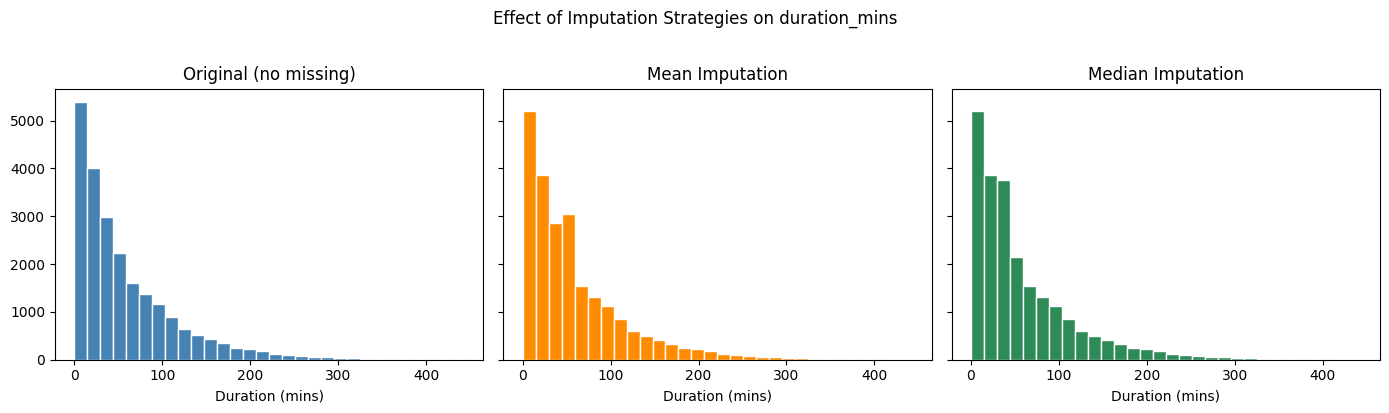

In [59]:
# Compare original vs mean vs median imputation distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

axes[0].hist(sessions["duration_mins"].dropna(), bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Original (no missing)")
axes[0].set_xlabel("Duration (mins)")

axes[1].hist(sessions_mean["duration_mins"], bins=30, color="darkorange", edgecolor="white")
axes[1].set_title("Mean Imputation")
axes[1].set_xlabel("Duration (mins)")

axes[2].hist(sessions_median["duration_mins"], bins=30, color="seagreen", edgecolor="white")
axes[2].set_title("Median Imputation")
axes[2].set_xlabel("Duration (mins)")

plt.suptitle("Effect of Imputation Strategies on duration_mins", y=1.02)
plt.tight_layout()
plt.show()

both strategies preserve the overall right skewed shape pretty well. mean imputation creates a small spike around 59 mins, while median imputation creates one around 39 mins. the median version stays closer to the original distribution since 39 is nearer to where most sessions actually cluster, making it the better choice here.

**Outlier strategy 1: remove outliers (IQR)**

In [60]:
# Strategy 1: Remove outliers from chat_messages_sent using IQR
Q1 = sessions_exp["chat_messages_sent"].quantile(0.25)
Q3 = sessions_exp["chat_messages_sent"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

sessions_removed = sessions_exp[
    (sessions_exp["chat_messages_sent"] >= lower) &
    (sessions_exp["chat_messages_sent"] <= upper)
]

print(f"Rows before: {len(sessions_exp)}")
print(f"Rows after removing outliers: {len(sessions_removed)}")
print(f"Rows removed: {len(sessions_exp) - len(sessions_removed)}")
print(sessions_removed["chat_messages_sent"].describe())

Rows before: 22825
Rows after removing outliers: 20668
Rows removed: 2157
count    20668.000000
mean         2.619605
std          3.521257
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max         15.000000
Name: chat_messages_sent, dtype: float64


strategy 1 removes any row outside the IQR bounds, dropping 2157 rows (including the 342 artificial outliers we added plus existing ones). the mean drops from 58 back down to 2.6 and the max is now 15, showing the method works but at the cost of losing real data alongside the outliers.

**Outlier strategy 2:

In [64]:
# Strategy 2: Replace outliers with the column median
sessions_median_out = sessions_exp.copy()
median_chat = sessions_median_out["chat_messages_sent"].median()
sessions_median_out.loc[
    (sessions_median_out["chat_messages_sent"] < lower) |
    (sessions_median_out["chat_messages_sent"] > upper),
    "chat_messages_sent"
] = median_chat

print(f"Median used for replacement: {median_chat}")
print(f"Max before: {sessions_exp['chat_messages_sent'].max()}")
print(f"Max after: {sessions_median_out['chat_messages_sent'].max()}")
print(sessions_median_out["chat_messages_sent"].describe())

Median used for replacement: 1.0
Max before: 4998
Max after: 15
count    22825.000000
mean         2.466550
std          3.384069
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max         15.000000
Name: chat_messages_sent, dtype: float64


**Compare the two outlier strategies visually**

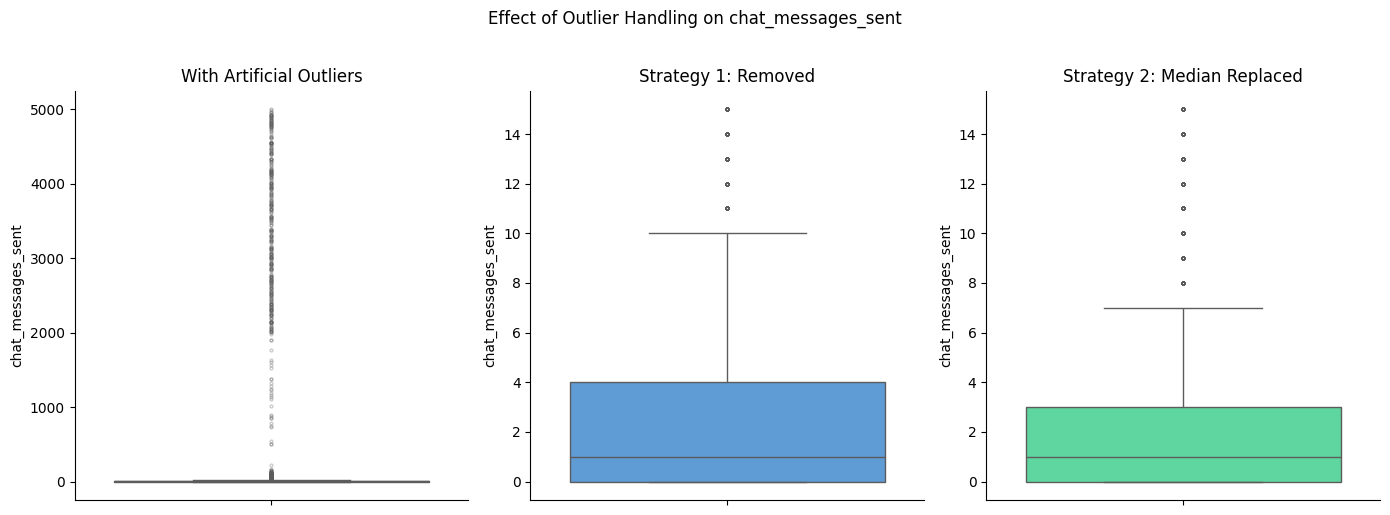

In [65]:
# Compare outlier handling strategies
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.boxplot(data=sessions_exp, y="chat_messages_sent", ax=axes[0], color="#E87B4C",
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[0].set_title("With Artificial Outliers")

sns.boxplot(data=sessions_removed, y="chat_messages_sent", ax=axes[1], color="#4C9BE8",
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[1].set_title("Strategy 1: Removed")

sns.boxplot(data=sessions_median_out, y="chat_messages_sent", ax=axes[2], color="#4CE8A0",
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[2].set_title("Strategy 2: Median Replaced")

sns.despine()
plt.suptitle("Effect of Outlier Handling on chat_messages_sent", y=1.02)
plt.tight_layout()
plt.show()

the difference is clear. with artificial outliers the box is completely crushed at the bottom with values shooting up to 5000. after removal the scale drops to 15 and the distribution looks normal. median replacement gives a very similar result while keeping all 22825 rows, making it the better option since no data is lost.

### Task 4 Summary report

in task 4 i audited missing values and outliers across all four tables and the derived merged data.
missing values existed in the original data across sessions, viewers, streamers, and streams. since
`duration_mins` had no missing values, i artificially introduced 4% (913 rows) to test two imputation
strategies. median imputation was the better fit for this skewed column since it fills closer to where
most sessions actually cluster.

for outliers, `chat_messages_sent` had artificial outliers introduced
at 1.5% (342 rows). removing outliers via IQR cleaned the data effectively but lost 2157 rows total.
replacing with the median kept all rows while still bringing the distribution back to a reasonable range,
making it the preferred approach here.

# Task 5: Correlation and Behavioral Patterns

- Compute pairwise correlations between user features and the number of check-ins  
- Visualize the results using a correlation matrix (use a coolwarm color scheme and proper scaling)  
- Try Spearman rank correlation and explain when it is more appropriate than Pearson

**Build the merged dataset for correlation**

In [66]:
# Merge sessions with viewers and streams to get all relevant features together
sessions_full = sessions.merge(viewers, on="viewer_id").merge(streams, on="stream_id")
sessions_full.head(3)

,session_id,viewer_id,streamer_id_x,stream_id,started_at_x,ended_at_x,duration_mins,chat_messages_sent,bits_cheered,followed_during,...,subscription_tier,preferred_category,streamer_id_y,started_at_y,ended_at_y,stream_duration_hrs,category,peak_viewers,title_has_hype_word,was_raid
0,SES000001,VWR00938,STR0055,SM00860,2024-01-18 19:16:00,2024-01-18 20:28:00,72,0,0,False,...,free,Just Chatting,STR0055,2024-01-18 18:00:00,2024-01-18 22:00:00,4.0,Creative,4619.0,False,False
1,SES000002,VWR00804,STR0034,SM00542,2024-01-04 17:11:00,2024-01-04 19:41:00,150,11,0,False,...,tier1,FPS,STR0034,2024-01-04 14:00:00,2024-01-04 21:00:00,7.0,MOBA,13782.0,False,False
2,SES000003,VWR00704,STR0008,SM00124,2024-02-15 15:11:00,2024-02-15 16:53:00,102,5,0,False,...,tier1,MOBA,STR0008,2024-02-15 13:00:00,2024-02-15 20:00:00,7.0,Just Chatting,935.0,True,False


i merged sessions with viewers and streams to create one combined table with 25 columns. this gives me viewer demographics, session behavior, and stream metadata all in one place to run correlations across.

**Pearson correlation matrix**

In [67]:
# Select numerical columns relevant to behavior
corr_cols = ["duration_mins", "chat_messages_sent", "bits_cheered",
             "account_age_days", "stream_duration_hrs", "peak_viewers"]

corr_matrix = sessions_full[corr_cols].corr(method="pearson")
print(corr_matrix.round(2))

                     duration_mins  chat_messages_sent  bits_cheered  \
duration_mins                 1.00                0.09          0.00   
chat_messages_sent            0.09                1.00         -0.01   
bits_cheered                  0.00               -0.01          1.00   
account_age_days             -0.00                0.01         -0.01   
stream_duration_hrs           0.11                0.03          0.02   
peak_viewers                  0.01                0.00          0.00   

                     account_age_days  stream_duration_hrs  peak_viewers  
duration_mins                   -0.00                 0.11          0.01  
chat_messages_sent               0.01                 0.03          0.00  
bits_cheered                    -0.01                 0.02          0.00  
account_age_days                 1.00                 0.01         -0.01  
stream_duration_hrs              0.01                 1.00          0.03  
peak_viewers                    -0.01        

almost all correlations are extremely close to zero, meaning none of these variables have a strong linear relationship with each other. the only slightly notable ones are duration_mins and stream_duration_hrs at 0.11, which makes sense since longer streams give viewers more time to watch. everything else is basically flat.

**Visualize Pearson correlation heatmap**

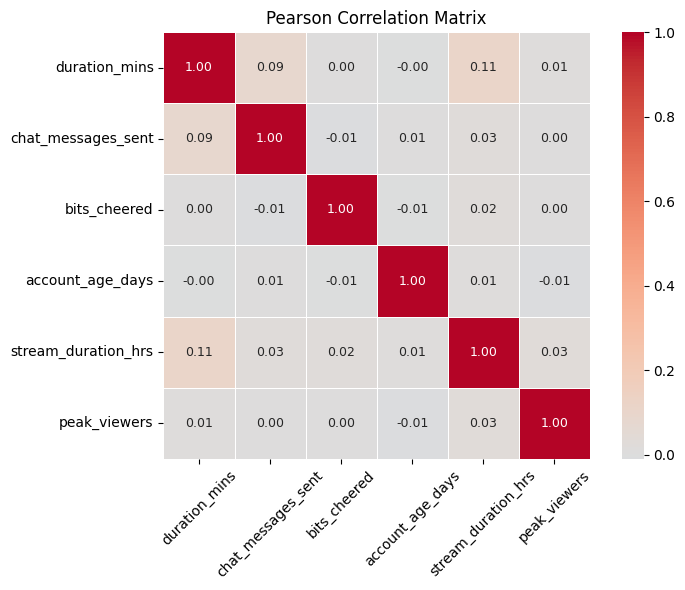

In [68]:
# Heatmap using coolwarm — same approach as lab 02
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True, ax=ax, annot_kws={"size": 9})
ax.set_title("Pearson Correlation Matrix")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

the heatmap confirms what the numbers showed. almost everything is grey meaning near zero correlation. the only slightly warm cell is duration_mins and stream_duration_hrs at 0.11. the diagonal is all 1.00 as expected since each variable perfectly correlates with itself. overall this dataset doesn't show strong linear relationships between these behavioral and viewer features.

**Spearman correlation matrix**

In [69]:
# Spearman rank correlation
spearman_matrix = sessions_full[corr_cols].corr(method="spearman")
print(spearman_matrix.round(2))

                     duration_mins  chat_messages_sent  bits_cheered  \
duration_mins                 1.00                0.65          0.00   
chat_messages_sent            0.65                1.00         -0.01   
bits_cheered                  0.00               -0.01          1.00   
account_age_days             -0.01                0.01         -0.00   
stream_duration_hrs           0.33                0.22          0.00   
peak_viewers                  0.00                0.01          0.00   

                     account_age_days  stream_duration_hrs  peak_viewers  
duration_mins                   -0.01                 0.33          0.00  
chat_messages_sent               0.01                 0.22          0.01  
bits_cheered                    -0.00                 0.00          0.00  
account_age_days                 1.00                 0.01         -0.01  
stream_duration_hrs              0.01                 1.00          0.02  
peak_viewers                    -0.01        

spearman tells a very different story. duration_mins and chat_messages_sent jump to 0.65, and duration_mins with stream_duration_hrs goes up to 0.33. pearson missed these because it assumes linear relationships and is sensitive to the heavy skew and outliers in these columns. spearman works on ranks instead, making it much more appropriate here since columns like chat_messages_sent and bits_cheered are heavily skewed with lots of zeros.

**Visualize Spearman heatmap**

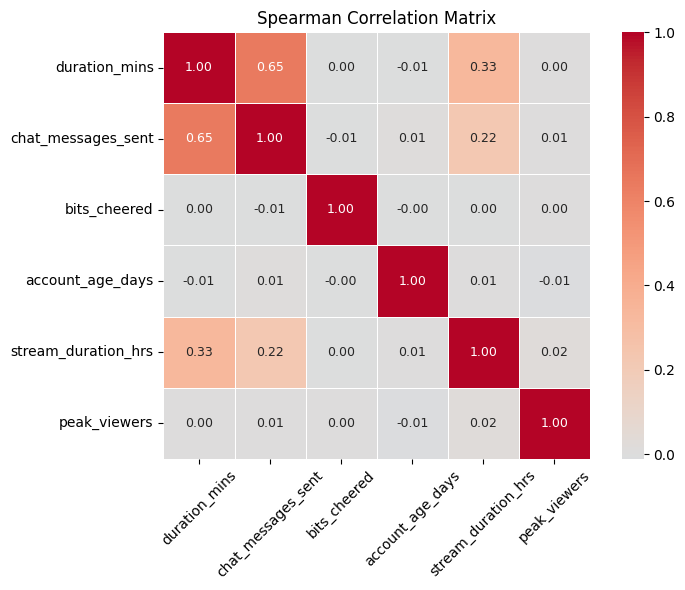

In [70]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(spearman_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True, ax=ax, annot_kws={"size": 9})
ax.set_title("Spearman Correlation Matrix")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

the spearman heatmap makes the relationships much more visible. the 0.65 between duration_mins and chat_messages_sent makes intuitive sense.. the longer someone watches, the more they chat. the 0.33 between duration_mins and stream_duration_hrs also shows up clearly here. compared to the pearson heatmap which was almost entirely grey, spearman gives a much more informative picture of how these behavioral variables actually relate to each other.

**Compare Pearson vs Spearman side by side**

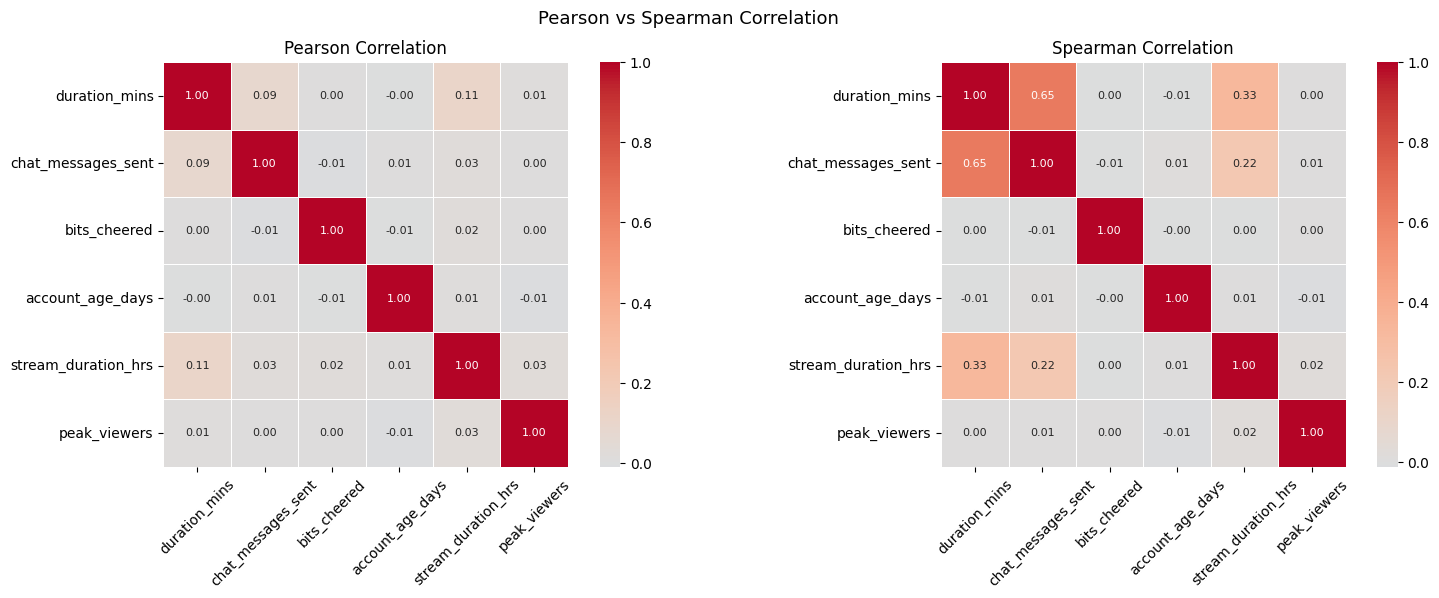

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True, ax=axes[0], annot_kws={"size": 8})
axes[0].set_title("Pearson Correlation")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(spearman_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True, ax=axes[1], annot_kws={"size": 8})
axes[1].set_title("Spearman Correlation")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Pearson vs Spearman Correlation", fontsize=13)
plt.tight_layout()
plt.show()

the side by side comparison really highlights the difference. pearson is almost completely grey while spearman picks up meaningful patterns, especially the 0.65 between duration_mins and chat_messages_sent. spearman is more appropriate here because most of these columns are heavily skewed and not normally distributed, which violates pearson's assumptions. spearman only looks at the rank order of values so it handles skewed and outlier heavy data much better.

### Task 5 Summary report

in task 5 i computed pairwise correlations between session behavior and viewer features using both pearson and spearman methods. pearson returned near zero correlations across the board, suggesting no strong linear relationships. spearman told a more meaningful story, revealing a moderate positive correlation of 0.65 between `duration_mins` and `chat_messages_sent`, meaning viewers who watch longer also tend to chat more. spearman is the better choice here because the data is heavily skewed and non normal, which makes pearson unreliable. the side by side heatmap comparison makes this difference very clear visually.

# Task 6: Compare Behavior Across User Segments

- Segment users into 2–3 groups (e.g., by age bracket, account tire)  
- Compare their viewing behavior over time using boxplots or dot plots  
- Identify any outliers in group behavior and investigate them

**Set up the merged data for segmentation**

In [72]:
# before anything, merging sessions with viewers so i have both behavior + demographics in one place
# dropping rows where subscription_tier is null since thats the segment i want to compare
seg_df = sessions.merge(viewers, on="viewer_id")
seg_df = seg_df.dropna(subset=["subscription_tier"])

print(seg_df["subscription_tier"].value_counts())
print(f"\ntotal rows after dropping nulls: {len(seg_df)}")

subscription_tier
free     13499
tier1     5526
tier2     2074
tier3     1153
Name: count, dtype: int64

total rows after dropping nulls: 22252


after merging and dropping null subscription tiers i have 22,252 sessions left. free tier has the most sessions by far (13,499) which makes sense since thats the most common tier in the dataset.

**Segment 1: viewing duration by subscription tier (boxplot)**

/tmp/ipykernel_6407/2046724949.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


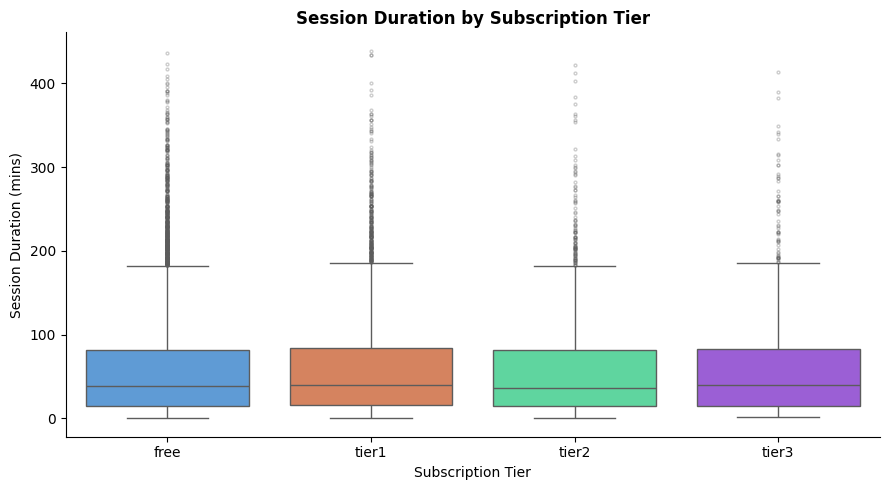

In [73]:
# comparing how long people watch based on their subscription tier
# using boxplot because i want to see spread + outliers, not just averages
fig, ax = plt.subplots(figsize=(9, 5))

tier_order = ["free", "tier1", "tier2", "tier3"]

sns.boxplot(
    data=seg_df,
    x="subscription_tier",
    y="duration_mins",
    order=tier_order,
    palette=["#4C9BE8", "#E87B4C", "#4CE8A0", "#9B4CE8"],
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

ax.set_title("Session Duration by Subscription Tier", fontweight="bold")
ax.set_xlabel("Subscription Tier")
ax.set_ylabel("Session Duration (mins)")
sns.despine()
plt.tight_layout()
plt.show()

the boxplot shows session duration across all four tiers. i followed the boxplot approach from the lab02 tutorial. all four groups look nearly identical with medians around 40-45 mins and similar spreads, so subscription tier doesn't seem to predict how long someone watches. outliers above 400 mins appear in every tier equally.

**Segment 2: chat activity by subscription tier**

/tmp/ipykernel_6407/3789775454.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


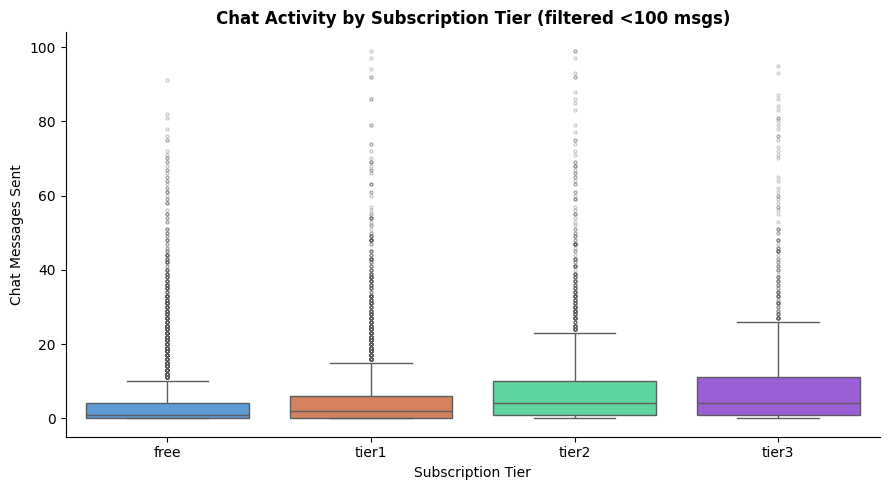

In [74]:
# do higher tier subscribers chat more? checking chat_messages_sent across tiers
# filtering to under 100 messages so the plot is actually readable (outliers crush the scale otherwise)
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=seg_df[seg_df["chat_messages_sent"] < 100],
    x="subscription_tier",
    y="chat_messages_sent",
    order=tier_order,
    palette=["#4C9BE8", "#E87B4C", "#4CE8A0", "#9B4CE8"],
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

ax.set_title("Chat Activity by Subscription Tier (filtered <100 msgs)", fontweight="bold")
ax.set_xlabel("Subscription Tier")
ax.set_ylabel("Chat Messages Sent")
sns.despine()
plt.tight_layout()
plt.show()

chat activity actually does differ across tiers unlike duration. free tier viewers send the fewest messages with a median close to 0, while tier2 and tier3 subscribers chat noticeably more. i filtered to under 100 messages so the plot stays readable since the outliers were crushing the scale. higher tier subscribers seem more engaged in chat which makes intuitive sense since they're already invested enough to pay more.

**Segment 3: age group comparison on duration (dot plot style)**

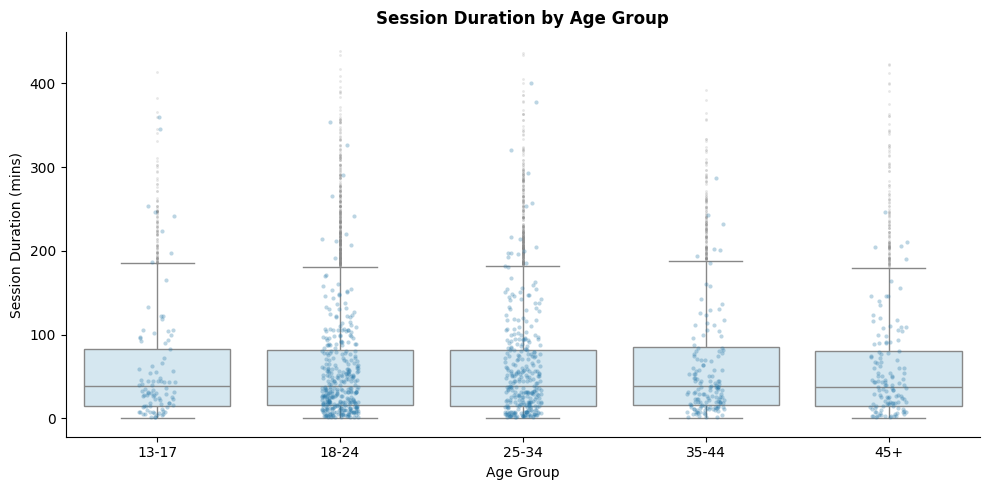

In [75]:
# now switching segments to age group — comparing average duration + spread
# using a strip plot layered over boxplot so i can see individual points too
fig, ax = plt.subplots(figsize=(10, 5))

age_order = ["13-17", "18-24", "25-34", "35-44", "45+"]

sns.boxplot(
    data=seg_df,
    x="age_group",
    y="duration_mins",
    order=age_order,
    color="#d0e8f5",
    flierprops=dict(marker='o', markersize=1, alpha=0.2),
    ax=ax
)

sns.stripplot(
    data=seg_df.sample(1000, random_state=42),
    x="age_group",
    y="duration_mins",
    order=age_order,
    color="#2274A5",
    alpha=0.3,
    size=3,
    ax=ax
)

ax.set_title("Session Duration by Age Group", fontweight="bold")
ax.set_xlabel("Age Group")
ax.set_ylabel("Session Duration (mins)")
sns.despine()
plt.tight_layout()
plt.show()

i layered a strip plot over the boxplot following the lab03 tutorial approach so i could see individual points alongside the distribution. all age groups show nearly identical medians around 40-45 mins with similar spreads. the individual dots confirm there's no real separation between groups. age doesn't seem to influence how long someone watches any more than subscription tier did.

**Investigate outliers within segments**

In [76]:
# investigating the outliers — who are the extreme watchers in each tier?
# looking at sessions over 300 mins and seeing which tier they belong to
extreme_sessions = seg_df[seg_df["duration_mins"] > 300]

print(f"sessions over 300 mins: {len(extreme_sessions)}")
print()
print(extreme_sessions["subscription_tier"].value_counts())
print()
print(extreme_sessions[["viewer_id", "subscription_tier", "age_group", "duration_mins"]].sort_values("duration_mins", ascending=False).head(10))

sessions over 300 mins: 148

subscription_tier
free     85
tier1    38
tier2    13
tier3    12
Name: count, dtype: int64

      viewer_id subscription_tier age_group  duration_mins
3728   VWR00921             tier1     18-24            439
9868   VWR00082              free     25-34            436
14924  VWR00899             tier1     25-34            434
5927   VWR00813             tier1     18-24            434
112    VWR00844              free       45+            423
5482   VWR00942             tier2       45+            422
7188   VWR00390              free     18-24            417
2298   VWR00539             tier3     13-17            414
5804   VWR00869             tier2       45+            412
5338   VWR00467              free     18-24            409


148 sessions exceeded 300 mins total. free tier has the most extreme watchers (85) which makes sense since it also has the most sessions overall. the top session hit 439 mins and interestingly it belongs to a tier1 viewer in the 18-24 group. extreme sessions are spread across all tiers and age groups so long watching isn't specific to any one segment.

**Summary stats per segment**

In [77]:
# clean summary table — mean, median, std of duration by tier
# this gives me the numbers to back up what the plots show
print("=== SESSION DURATION BY SUBSCRIPTION TIER ===")
print(seg_df.groupby("subscription_tier")["duration_mins"].agg(["mean", "median", "std"]).round(2))

print("\n=== CHAT ACTIVITY BY SUBSCRIPTION TIER ===")
print(seg_df.groupby("subscription_tier")["chat_messages_sent"].agg(["mean", "median", "std"]).round(2))

print("\n=== SESSION DURATION BY AGE GROUP ===")
print(seg_df.groupby("age_group")["duration_mins"].agg(["mean", "median", "std"]).round(2))

=== SESSION DURATION BY SUBSCRIPTION TIER ===
                    mean  median    std
subscription_tier                      
free               58.55    39.0  59.45
tier1              60.15    40.0  61.78
tier2              58.42    36.0  60.40
tier3              60.65    40.0  63.06

=== CHAT ACTIVITY BY SUBSCRIPTION TIER ===
                    mean  median    std
subscription_tier                      
free                5.28     1.0  49.47
tier1               6.98     2.0  44.50
tier2              11.13     4.0  48.15
tier3              10.49     4.0  23.20

=== SESSION DURATION BY AGE GROUP ===
            mean  median    std
age_group                      
13-17      58.91    39.0  59.79
18-24      58.99    39.0  60.50
25-34      58.83    39.0  59.87
35-44      60.01    39.0  60.49
45+        58.73    38.0  61.12


the numbers confirm what the plots showed. session duration medians are nearly identical across all tiers (39-40 mins) and all age groups (38-39 mins) so neither segment predicts watch time. chat activity is where the real difference shows up, free tier median is 1 message while tier2 and tier3 are at 4, and tier3 has the lowest std (23.20) meaning paid subscribers are more consistently chatty rather than just occasionally chatty.

### Task 6 Summary report

in task 6 i segmented users by subscription tier and age group and compared their viewing behavior. session duration was nearly identical across all segments with medians around 39-40 mins regardless of tier or age, which was unexpected. chat activity was the one behavior that actually differed by tier, higher tier subscribers send more messages on average with tier2 and tier3 having medians of 4 compared to 1 for free users. extreme sessions over 300 mins appeared across all segments with no group standing out as unusually prone to long watching. overall subscription tier explains engagement style better than it explains viewing duration.

# Task 7: Your Own EDA Questions

Formulate and explore two hypotheses of your own:  
- Propose questions based on curiosity (e.g., “Does a user's variety of categories influence morning vs. evening or session duration?”)  
- Use summary statistics and visualizations to answer each question  
- Briefly discuss what additional data would help you answer the questions more effectively


## **Question 1: Do viewers who follow or subscribe during a session watch longer than those who don't?**

to answer this question i used side by side boxplots following the same approach from the lab02 tutorial where we compared distributions across groups. i grouped sessions by whether followed_during or subscribed_during was true or false and plotted duration_mins for each group so i could see the full spread not just averages.

/tmp/ipykernel_6407/3894357970.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6407/3894357970.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


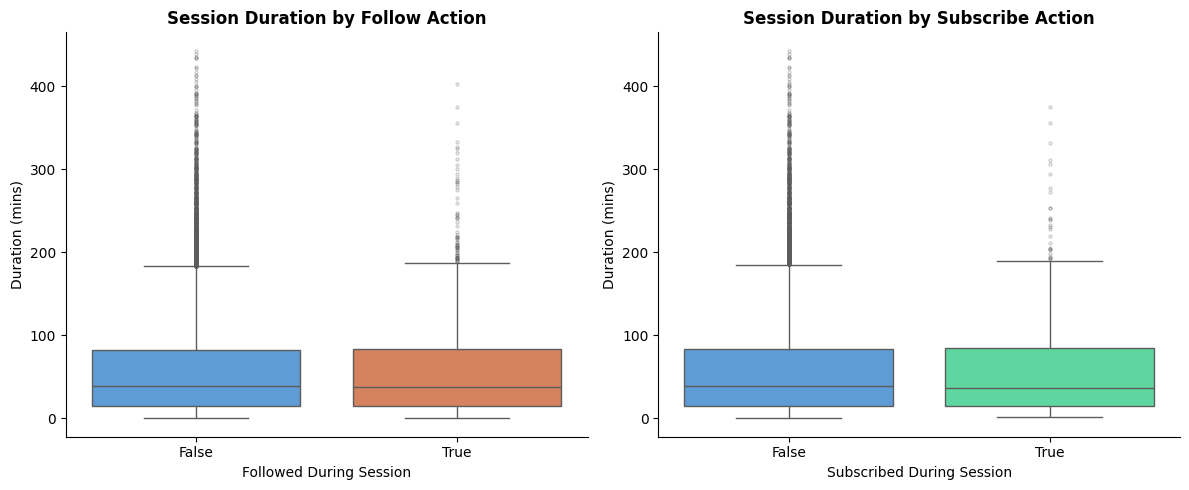

In [78]:
# question 1: do viewers who engage (follow/subscribe) during a session watch longer?
# grouping by whether they followed or subscribed and comparing duration
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=sessions,
    x="followed_during",
    y="duration_mins",
    palette=["#4C9BE8", "#E87B4C"],
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=axes[0]
)
axes[0].set_title("Session Duration by Follow Action", fontweight="bold")
axes[0].set_xlabel("Followed During Session")
axes[0].set_ylabel("Duration (mins)")

sns.boxplot(
    data=sessions,
    x="subscribed_during",
    y="duration_mins",
    palette=["#4C9BE8", "#4CE8A0"],
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=axes[1]
)
axes[1].set_title("Session Duration by Subscribe Action", fontweight="bold")
axes[1].set_xlabel("Subscribed During Session")
axes[1].set_ylabel("Duration (mins)")

sns.despine()
plt.tight_layout()
plt.show()

both plots look nearly identical between true and false groups. viewers who followed or subscribed during a session don't seem to watch noticeably longer than those who didn't.

In [79]:
# backing up the plots with numbers
print("=== DURATION BY FOLLOWED DURING ===")
print(sessions.groupby("followed_during")["duration_mins"].agg(["mean", "median", "std"]).round(2))

print("\n=== DURATION BY SUBSCRIBED DURING ===")
print(sessions.groupby("subscribed_during")["duration_mins"].agg(["mean", "median", "std"]).round(2))

=== DURATION BY FOLLOWED DURING ===
                  mean  median    std
followed_during                      
False            59.02    39.0  60.30
True             59.60    38.0  61.96

=== DURATION BY SUBSCRIBED DURING ===
                    mean  median    std
subscribed_during                      
False              58.99    39.0  60.27
True               62.26    37.0  66.05


the numbers back that up. for following, the medians are 39 vs 38 mins, basically the same. subscribing shows a slightly higher mean (62.26 vs 58.99) but the median is actually lower for subscribers (37 vs 39), which means a few very long sessions are pulling the mean up rather than subscribers genuinely watching longer. the std is also higher for subscribers (66.05) confirming more variability rather than a clear pattern.

additional data that would help: knowing whether these viewers returned to the same streamer in future sessions would be way more useful here. a single session can't really tell you if following or subscribing is a cause or effect of watching longer.

## **Question 2: Do streams that were raids attract more peak viewers than non-raid streams?**

/tmp/ipykernel_6407/1349533945.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


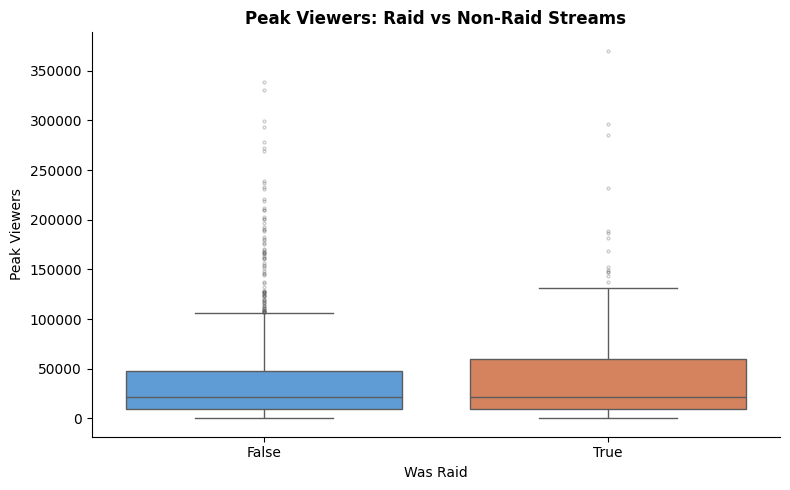

In [82]:
# question 2: do raid streams attract more peak viewers than non-raid streams?
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=streams,
    x="was_raid",
    y="peak_viewers",
    palette=["#4C9BE8", "#E87B4C"],
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

ax.set_title("Peak Viewers: Raid vs Non-Raid Streams", fontweight="bold")
ax.set_xlabel("Was Raid")
ax.set_ylabel("Peak Viewers")
sns.despine()
plt.tight_layout()
plt.show()

to answer this question i used a boxplot comparing peak viewers between raid and non-raid streams, following the same groupby and boxplot approach from the lab02 and lab03 tutorials. out of 1199 streams, 167 were raids and 1032 were not.

the plot shows raid streams have a noticeably larger IQR box meaning more variability in peak viewers. the median is similar between both groups (around 21,000-22,000) but raid streams stretch higher on the upper end.

In [83]:
# summary stats for raid vs non-raid
print("=== PEAK VIEWERS BY RAID STATUS ===")
print(streams.groupby("was_raid")["peak_viewers"].agg(["mean", "median", "std"]).round(2))

print(f"\nraid streams: {streams['was_raid'].sum()}")
print(f"non-raid streams: {(~streams['was_raid']).sum()}")

=== PEAK VIEWERS BY RAID STATUS ===
              mean   median       std
was_raid                             
False     38759.19  21244.0  48903.80
True      45953.27  21998.5  60332.15

raid streams: 167
non-raid streams: 1032


the numbers confirm it. raid streams have a higher mean (45,953 vs 38,759) but nearly identical medians (21,999 vs 21,244). the much higher std for raids (60,332 vs 48,903) explains the gap, a few very high viewership raids are pulling the mean up. so raids don't consistently attract more viewers but when they do well they tend to do really well.

additional data that would help: knowing the size of the raiding streamer's audience would help a lot here since a raid from a streamer with 100k followers is very different from one with 1k. without that context it's hard to say whether raids themselves cause higher viewership or if it's just that bigger streamers raid more often.

### Task 7 Summary report

in task 7 i explored two questions. for question 1, viewers who followed or subscribed during a session did not watch significantly longer than those who didn't. medians were nearly identical across both groups suggesting in-session engagement actions aren't strongly tied to watch time. for question 2, raid streams showed a higher mean peak viewership than non-raid streams but similar medians, meaning raids don't consistently boost viewership but occasionally produce very high peaks. both questions would benefit from more contextual data like return visit history or raiding streamer size to draw stronger conclusions.

# Task 8: EDA Presentation (Insight Report)

Summarize your findings in a polished format:  
- Create 3–4 slides or a single-page report highlighting your most important insights  
- Include at least 2 charts and interpret them using clear, plain language  
- Apply Tufte’s principles: minimize chartjunk, maximize data-to-ink ratio, and ensure clear labeling  